In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import os
import warnings

warnings.filterwarnings("ignore")

os.makedirs("../report/plots", exist_ok=True)
os.makedirs("../data/exports", exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

print("Phase 3 EDA setup complete.")

Phase 3 EDA setup complete.


In [5]:
eda_cols = [
    "loan_amnt", "term", "int_rate", "installment",
    "grade", "sub_grade", "emp_length", "home_ownership",
    "annual_inc", "verification_status", "issue_d",
    "purpose", "addr_state", "dti", "delinq_2yrs",
    "earliest_cr_line", "fico_range_low", "fico_range_high",
    "open_acc", "pub_rec", "revol_bal", "revol_util",
    "total_acc", "mort_acc", "target"
]

df = pd.read_csv(
    "../data/processed/df_model_raw.csv",
    usecols=eda_cols,
    low_memory=False
)

print("EDA dataset shape:", df.shape)
print("Default rate:", round(df["target"].mean() * 100, 2), "%")
print("\nTarget counts:")
print(df["target"].value_counts())
print("\nColumns loaded:")
print(df.columns.tolist())

EDA dataset shape: (1348099, 25)
Default rate: 19.98 %

Target counts:
target
0    1078739
1     269360
Name: count, dtype: int64

Columns loaded:
['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'target']


In [6]:
# Clean term and create readable label
df["term"] = df["term"].astype(str).str.strip().str.replace(" months", "", regex=False)
df["term_label"] = df["term"].map({"36": "36 months", "60": "60 months"})

# Ensure int_rate is numeric
df["int_rate"] = pd.to_numeric(
    df["int_rate"].astype(str).str.replace("%", "", regex=False).str.strip(),
    errors="coerce"
)

# Convert date columns
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y", errors="coerce")

# Create date-based features
df["issue_year"] = df["issue_d"].dt.year
df["issue_month"] = df["issue_d"].dt.month

# Create EDA features
df["fico_avg"] = (df["fico_range_low"] + df["fico_range_high"]) / 2
df["loan_to_income_ratio"] = (df["loan_amnt"] / df["annual_inc"]).round(4)
df["installment_to_income_ratio"] = (df["installment"] / (df["annual_inc"] / 12)).round(4)
df["credit_history_years"] = ((df["issue_d"] - df["earliest_cr_line"]).dt.days / 365.25).round(1)

print("Light cleaning complete.")
print("Shape after feature creation:", df.shape)

print("\nMissing values in important EDA columns:")
important_cols = [
    "term_label", "int_rate", "issue_d", "earliest_cr_line",
    "issue_year", "issue_month", "fico_avg",
    "loan_to_income_ratio", "installment_to_income_ratio",
    "credit_history_years"
]
print(df[important_cols].isnull().sum())

Light cleaning complete.
Shape after feature creation: (1348099, 32)

Missing values in important EDA columns:
term_label                      0
int_rate                        0
issue_d                         0
earliest_cr_line               29
issue_year                      0
issue_month                     0
fico_avg                        0
loan_to_income_ratio            4
installment_to_income_ratio     4
credit_history_years           29
dtype: int64


In [7]:
print("Rows before dropping:", df.shape[0])

df = df.dropna(subset=[
    "earliest_cr_line",
    "credit_history_years",
    "loan_to_income_ratio",
    "installment_to_income_ratio"
])

print("Rows after dropping:", df.shape[0])

important_cols = [
    "term_label", "int_rate", "issue_d", "earliest_cr_line",
    "issue_year", "issue_month", "fico_avg",
    "loan_to_income_ratio", "installment_to_income_ratio",
    "credit_history_years"
]

print("\nMissing values after dropping:")
print(df[important_cols].isnull().sum())

print("\nDefault rate after dropping:")
print(round(df["target"].mean() * 100, 2), "%")

Rows before dropping: 1348099
Rows after dropping: 1348070

Missing values after dropping:
term_label                     0
int_rate                       0
issue_d                        0
earliest_cr_line               0
issue_year                     0
issue_month                    0
fico_avg                       0
loan_to_income_ratio           0
installment_to_income_ratio    0
credit_history_years           0
dtype: int64

Default rate after dropping:
19.98 %


## Phase 3 EDA Dataset Preparation

For exploratory data analysis, the Phase 1 modeling dataset `df_model_raw.csv` was used instead of the fully encoded Phase 2 dataset. This keeps human-readable categorical columns such as `grade`, `purpose`, `home_ownership`, `addr_state`, and `term`, which are required for business-friendly EDA charts.

Light cleaning was performed only for analysis purposes:
- Cleaned `term` and created `term_label`
- Converted `issue_d` and `earliest_cr_line` into datetime format
- Created `issue_year`, `issue_month`, `fico_avg`, `loan_to_income_ratio`, `installment_to_income_ratio`, and `credit_history_years`
- Dropped a very small number of rows with missing values in important EDA features

The final EDA dataset has 1,348,070 rows with a default rate of approximately 19.98%.

In [8]:
target_counts = df["target"].value_counts().sort_index()
target_pct = df["target"].value_counts(normalize=True).sort_index() * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentage:")
print(target_pct)

Target counts:
target
0    1078713
1     269357
Name: count, dtype: int64

Target percentage:
target
0    80.019064
1    19.980936
Name: proportion, dtype: float64


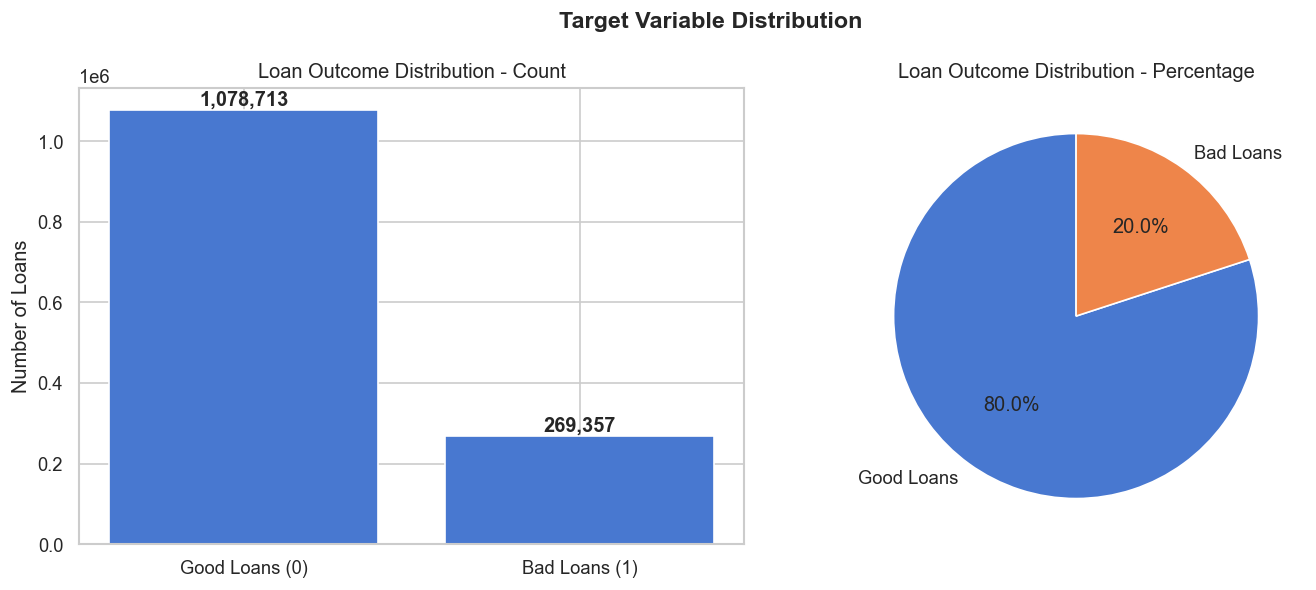

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ["Good Loans (0)", "Bad Loans (1)"]

# Count bar chart
axes[0].bar(labels, target_counts.values)
axes[0].set_title("Loan Outcome Distribution - Count")
axes[0].set_ylabel("Number of Loans")

for i, value in enumerate(target_counts.values):
    axes[0].text(i, value, f"{value:,}", ha="center", va="bottom", fontweight="bold")

# Percentage pie chart
axes[1].pie(
    target_counts.values,
    labels=["Good Loans", "Bad Loans"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Loan Outcome Distribution - Percentage")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("../report/plots/01_target_distribution.png", bbox_inches="tight")
plt.show()

### Insight: Target Variable Distribution

The dataset contains 1,078,713 good loans and 269,357 bad loans. Good loans make up approximately 80.02% of the dataset, while bad loans make up 19.98%.

This shows a moderate class imbalance, which is important for the modeling phase. During model building, evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix should be used instead of relying only on accuracy.

In [10]:
num_cols = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_avg",
    "revol_util",
    "open_acc",
    "loan_to_income_ratio"
]

df[num_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T

,count,mean,std,min,1%,25%,50%,75%,99%,max
loan_amnt,1348070.0,1.440922e+04,8716.088716,500.0000,1500.0000,7975.0000,12000.00,20000.0000,35000.00,40000.00
int_rate,1348070.0,1.324165e+01,4.765697,5.3100,5.3200,9.7500,12.74,15.9900,26.30,30.99
annual_inc,1348070.0,7.623784e+04,69922.833774,0.0000,18000.0000,45750.8600,65000.00,90000.0000,251000.00,10999200.00
dti,1347696.0,1.827448e+01,11.155488,-1.0000,1.7700,11.7900,17.61,24.0500,38.47,999.00
fico_avg,1348070.0,6.981617e+02,31.850557,612.0000,662.0000,672.0000,692.00,712.0000,802.00,847.50
revol_util,1347202.0,5.181200e+01,24.529794,0.0000,1.1000,33.4000,52.20,70.7000,98.20,892.30
open_acc,1348070.0,1.159045e+01,5.474680,0.0000,3.0000,8.0000,11.00,14.0000,29.00,90.00
loan_to_income_ratio,1348070.0,inf,NaN,0.0002,0.0255,0.1244,0.20,0.2909,0.50,inf


In [11]:
# Replace infinity values with NaN
df["loan_to_income_ratio"] = df["loan_to_income_ratio"].replace([np.inf, -np.inf], np.nan)
df["installment_to_income_ratio"] = df["installment_to_income_ratio"].replace([np.inf, -np.inf], np.nan)

print("Missing after replacing infinity:")
print(df[["loan_to_income_ratio", "installment_to_income_ratio"]].isnull().sum())

print("Rows before dropping:", df.shape[0])

# Drop rows where income ratio cannot be calculated
df = df.dropna(subset=["loan_to_income_ratio", "installment_to_income_ratio"])

print("Rows after dropping:", df.shape[0])
print("Default rate after dropping:", round(df["target"].mean() * 100, 2), "%")

Missing after replacing infinity:
loan_to_income_ratio           361
installment_to_income_ratio    361
dtype: int64
Rows before dropping: 1348070
Rows after dropping: 1347709
Default rate after dropping: 19.98 %


In [12]:
df[num_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T

,count,mean,std,min,1%,25%,50%,75%,99%,max
loan_amnt,1347709.0,14408.475791,8715.407105,500.0000,1500.0000,7975.0000,12000.00,20000.0000,35000.00,40000.00
int_rate,1347709.0,13.241163,4.765348,5.3100,5.3200,9.7500,12.74,15.9900,26.30,30.99
annual_inc,1347709.0,76258.257846,69921.062834,1.0000,18000.0000,45760.0000,65000.00,90000.0000,251000.00,10999200.00
dti,1347696.0,18.274480,11.155488,-1.0000,1.7700,11.7900,17.61,24.0500,38.47,999.00
fico_avg,1347709.0,698.158739,31.848737,612.0000,662.0000,672.0000,692.00,712.0000,802.00,847.50
revol_util,1346842.0,51.813068,24.528967,0.0000,1.1000,33.4000,52.20,70.7000,98.20,892.30
open_acc,1347709.0,11.591075,5.474685,0.0000,3.0000,8.0000,11.00,14.0000,29.00,90.00
loan_to_income_ratio,1347709.0,0.396870,70.756140,0.0002,0.0255,0.1244,0.20,0.2909,0.50,40000.00


In [13]:
print("Rows before final EDA cleaning:", df.shape[0])

# Drop rows where dti or revol_util is missing
df = df.dropna(subset=["dti", "revol_util"])

# Cap extreme values for clean EDA visuals
cap_cols = [
    "annual_inc",
    "dti",
    "revol_util",
    "open_acc",
    "loan_to_income_ratio",
    "installment_to_income_ratio"
]

for col in cap_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Rows after final EDA cleaning:", df.shape[0])
print("Default rate:", round(df["target"].mean() * 100, 2), "%")

Rows before final EDA cleaning: 1347709
Rows after final EDA cleaning: 1346829
Default rate: 19.98 %


In [14]:
df[num_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T

,count,mean,std,min,1%,25%,50%,75%,99%,max
loan_amnt,1346829.0,14410.081811,8714.272704,500.0000,1500.0000,7975.0000,12000.00,20000.0000,35000.00,40000.00
int_rate,1346829.0,13.240011,4.765074,5.3100,5.3200,9.7500,12.74,15.9900,26.30,30.99
annual_inc,1346829.0,74611.184311,42106.330340,18000.0000,18000.0000,45760.0000,65000.00,90000.0000,250000.00,250000.00
dti,1346829.0,18.130436,8.428216,1.7800,1.7800,11.7900,17.61,24.0500,38.47,38.47
fico_avg,1346829.0,698.150924,31.843480,612.0000,662.0000,672.0000,692.00,712.0000,802.00,847.50
revol_util,1346829.0,51.797561,24.449994,1.1000,1.1000,33.4000,52.20,70.7000,98.20,98.20
open_acc,1346829.0,11.551742,5.263047,3.0000,3.0000,8.0000,11.00,14.0000,29.00,29.00
loan_to_income_ratio,1346829.0,0.213279,0.113643,0.0255,0.0255,0.1244,0.20,0.2909,0.50,0.50


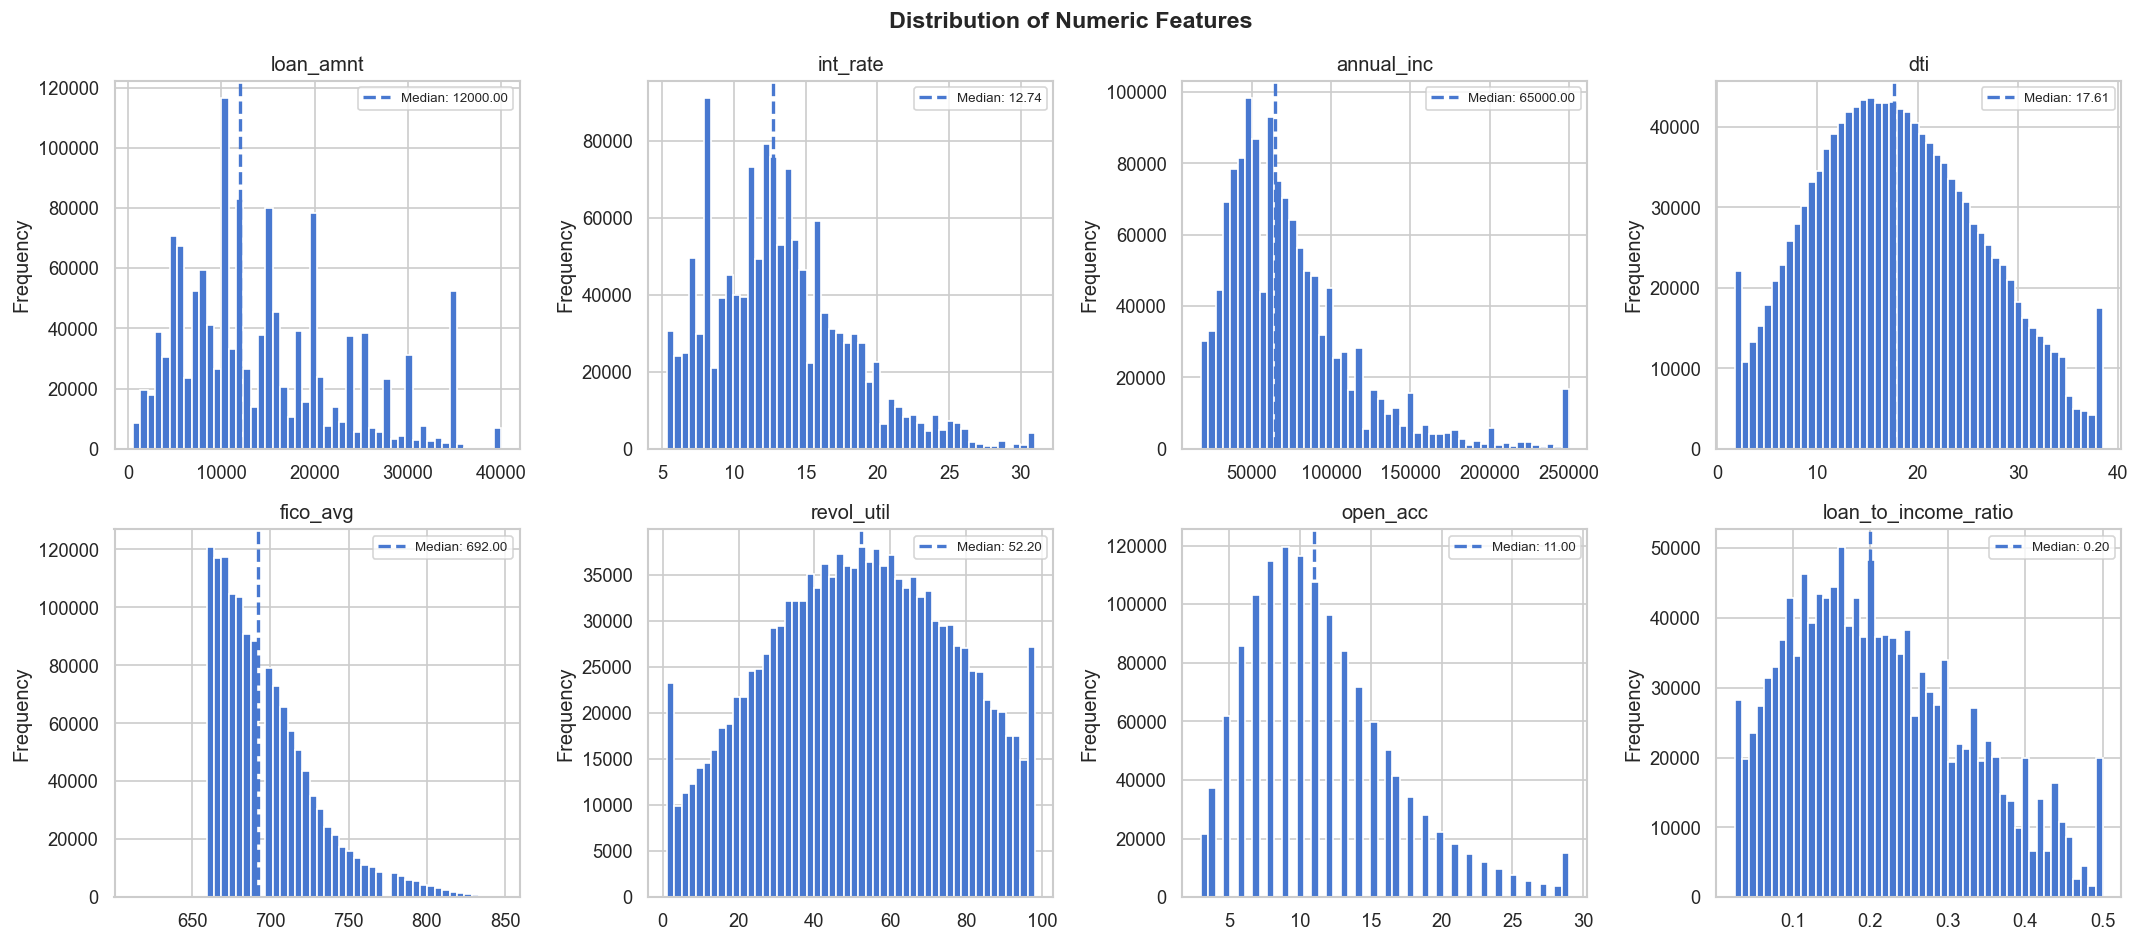

In [15]:
num_cols = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_avg",
    "revol_util",
    "open_acc",
    "loan_to_income_ratio"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor="white")
    axes[i].axvline(
        df[col].median(),
        linestyle="--",
        linewidth=2,
        label=f"Median: {df[col].median():.2f}"
    )
    axes[i].set_title(col)
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=8)

plt.suptitle("Distribution of Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("../report/plots/02_numeric_distributions.png", bbox_inches="tight")
plt.show()

### Insight: Numeric Feature Distributions

The numeric feature distributions show that most borrowers take loans between 5K and 20K, with median loan amount around 12K. Interest rates are mostly concentrated between 10% and 16%, while borrower income is right-skewed, with most annual incomes between 45K and 90K.

FICO scores are concentrated around the 670–710 range, which indicates that most borrowers have moderate to good credit profiles. DTI values are mostly between 10 and 25, showing moderate repayment burden. The loan-to-income ratio is mostly below 0.30, suggesting that most borrowers take loans smaller than 30% of their annual income.

These distributions help understand borrower financial profiles before analyzing how these features relate to default risk.

In [17]:
cat_cols = ["grade", "purpose", "home_ownership", "verification_status", "term_label"]

for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts())


 grade
grade
B    392827
C    381917
A    235067
D    201384
E     94072
F     32260
G      9302
Name: count, dtype: int64

 purpose
purpose
debt_consolidation    780861
credit_card           295468
home_improvement       87573
other                  78097
major_purchase         29501
medical                15581
small_business         15563
car                    14630
moving                  9501
vacation                9064
house                   7287
wedding                 2348
renewable_energy         935
educational              420
Name: count, dtype: int64

 home_ownership
home_ownership
MORTGAGE    666170
RENT        535275
OWN         144870
ANY            285
OTHER          180
NONE            49
Name: count, dtype: int64

 verification_status
verification_status
Source Verified    521242
Verified           418646
Not Verified       406941
Name: count, dtype: int64

 term_label
term_label
36 months    1022249
60 months     324580
Name: count, dtype: int64


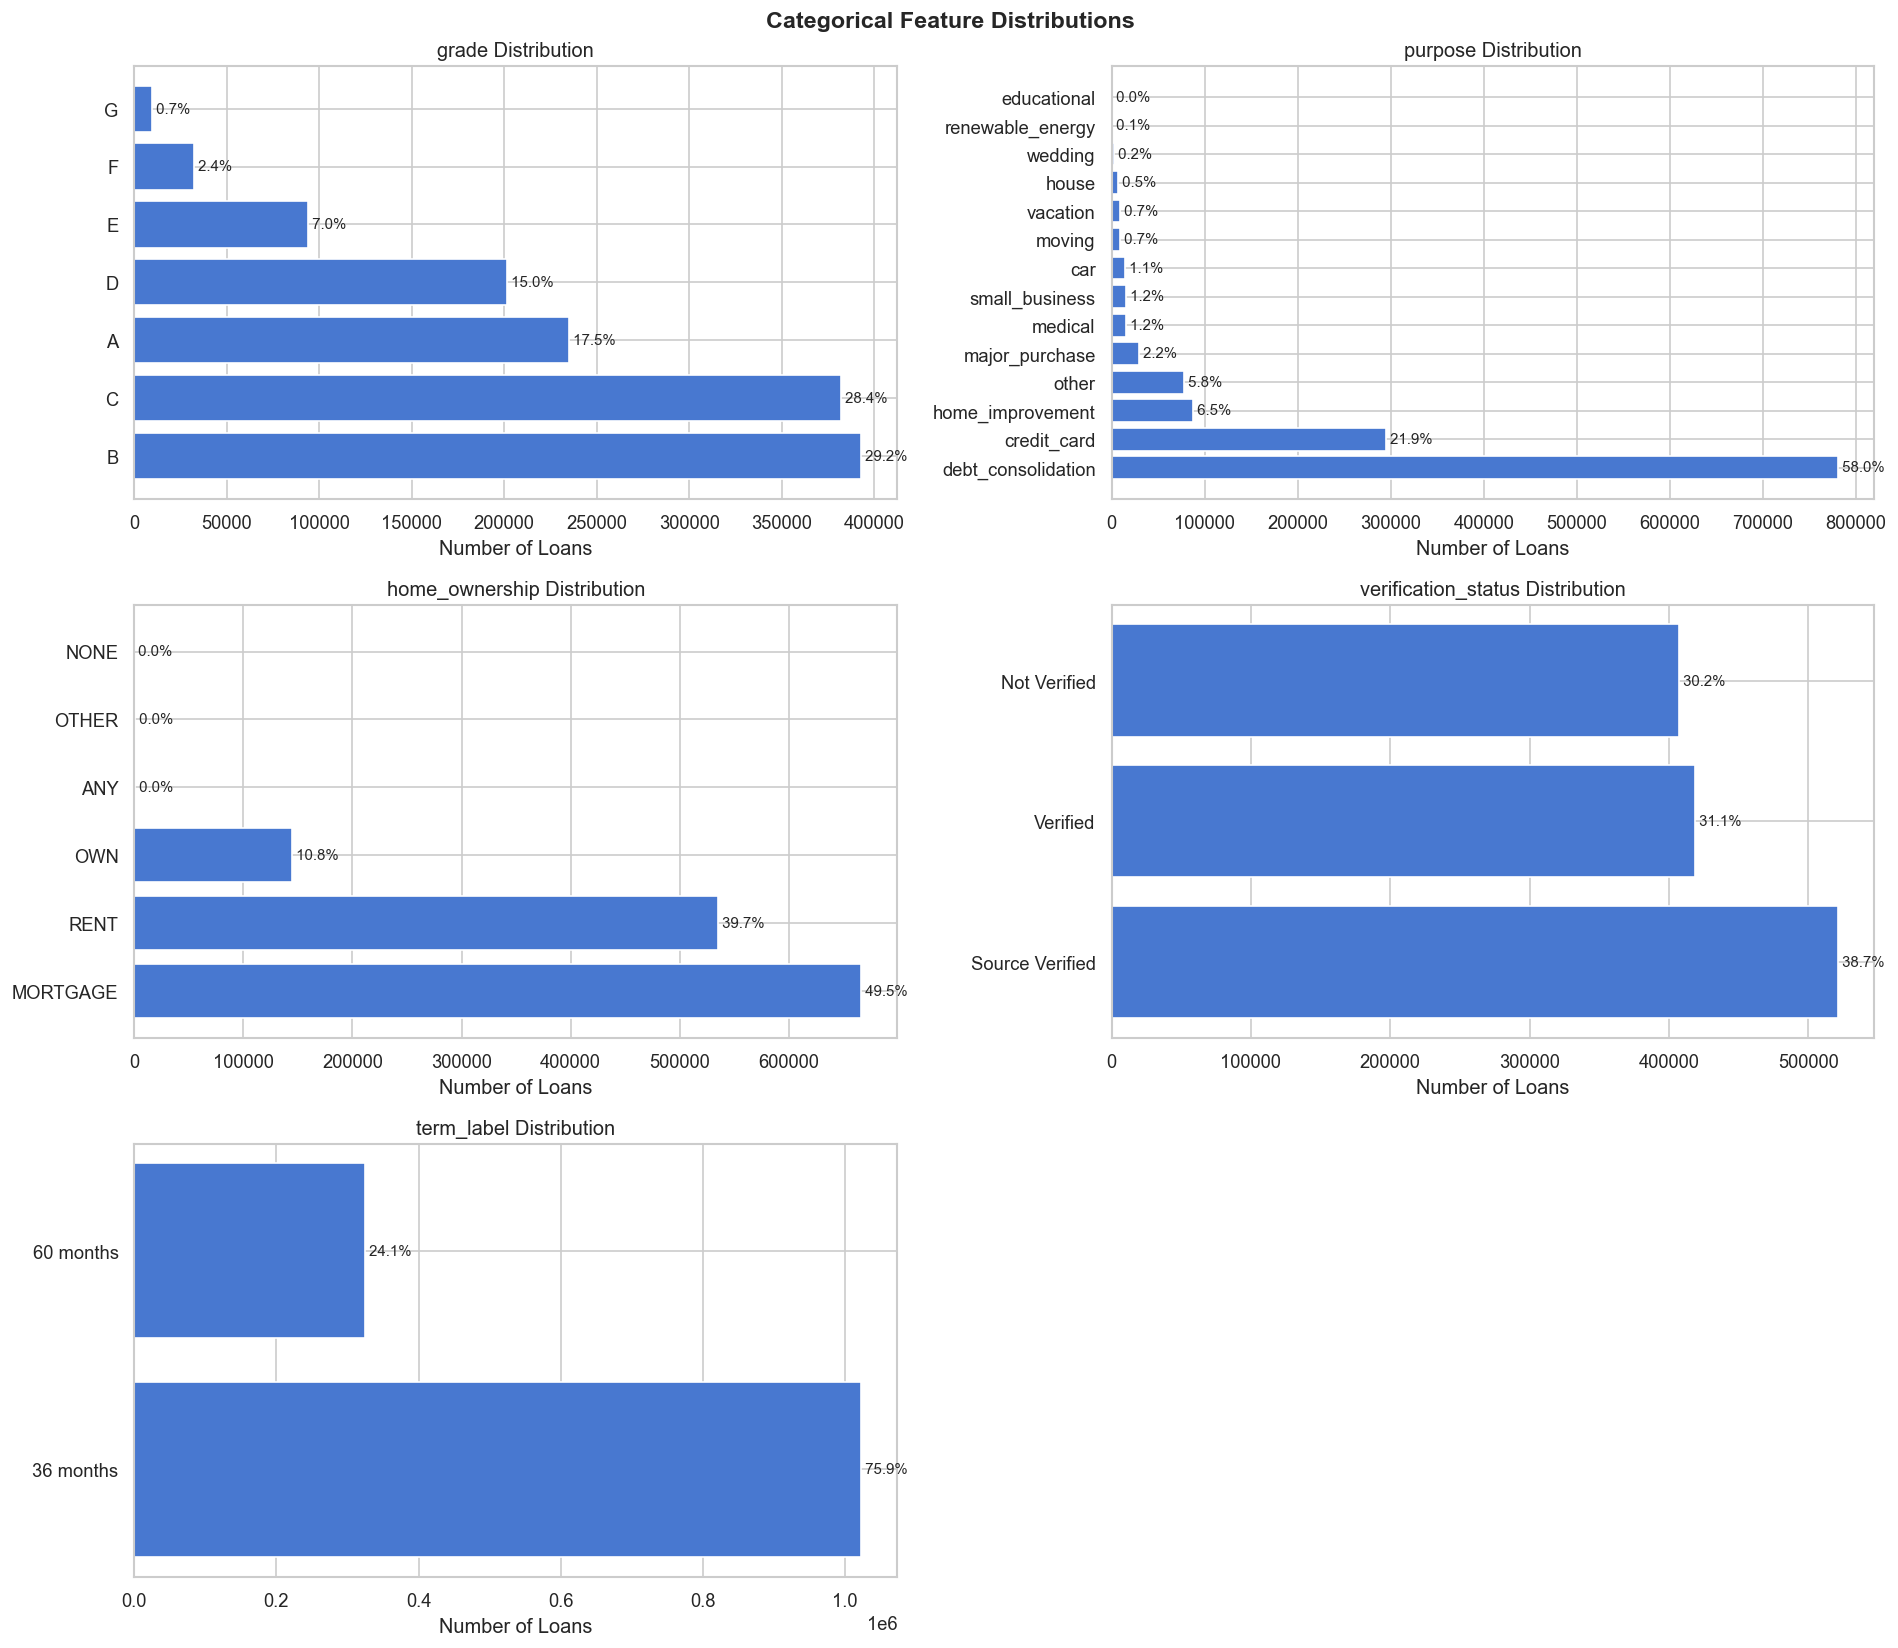

In [18]:
cat_cols = ["grade", "purpose", "home_ownership", "verification_status", "term_label"]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()

    axes[i].barh(counts.index.astype(str), counts.values)
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel("Number of Loans")

    for j, value in enumerate(counts.values):
        axes[i].text(
            value,
            j,
            f" {value / len(df) * 100:.1f}%",
            va="center",
            fontsize=9
        )

# Remove empty subplot
fig.delaxes(axes[-1])

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("../report/plots/03_categorical_distributions.png", bbox_inches="tight")
plt.show()

### Insight: Categorical Feature Distributions

The categorical distributions show that Grade B and Grade C loans are the most common, together covering more than half of the dataset. Debt consolidation is the dominant loan purpose, accounting for around 58% of loans, followed by credit card loans.

Most borrowers either have a mortgage or rent their home, while very few belong to categories such as ANY, OTHER, or NONE. Source Verified is the most common verification status. The majority of loans are 36-month loans, while 60-month loans form a smaller but significant portion of the dataset.

These patterns help identify the most common borrower and loan profiles before analyzing default risk by category.

In [19]:
category_cols = ["grade", "purpose", "home_ownership", "verification_status", "term_label"]

for col in category_cols:
    default_summary = (
        df.groupby(col)["target"]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={"mean": "default_rate"})
    )

    default_summary["default_rate_pct"] = (default_summary["default_rate"] * 100).round(2)
    default_summary = default_summary.sort_values("default_rate_pct", ascending=False)

    print("\n", col)
    print(default_summary)


 grade
  grade   count  default_rate  default_rate_pct
6     G    9302      0.496667             49.67
5     F   32260      0.451457             45.15
4     E   94072      0.384408             38.44
3     D  201384      0.303842             30.38
2     C  381917      0.224457             22.45
1     B  392827      0.133995             13.40
0     A  235067      0.060438              6.04

 purpose
               purpose   count  default_rate  default_rate_pct
11      small_business   15563      0.298593             29.86
10    renewable_energy     935      0.237433             23.74
8               moving    9501      0.234081             23.41
5                house    7287      0.219157             21.92
7              medical   15581      0.218664             21.87
2   debt_consolidation  780861      0.211549             21.15
9                other   78097      0.210892             21.09
3          educational     420      0.209524             20.95
12            vacation    9064 

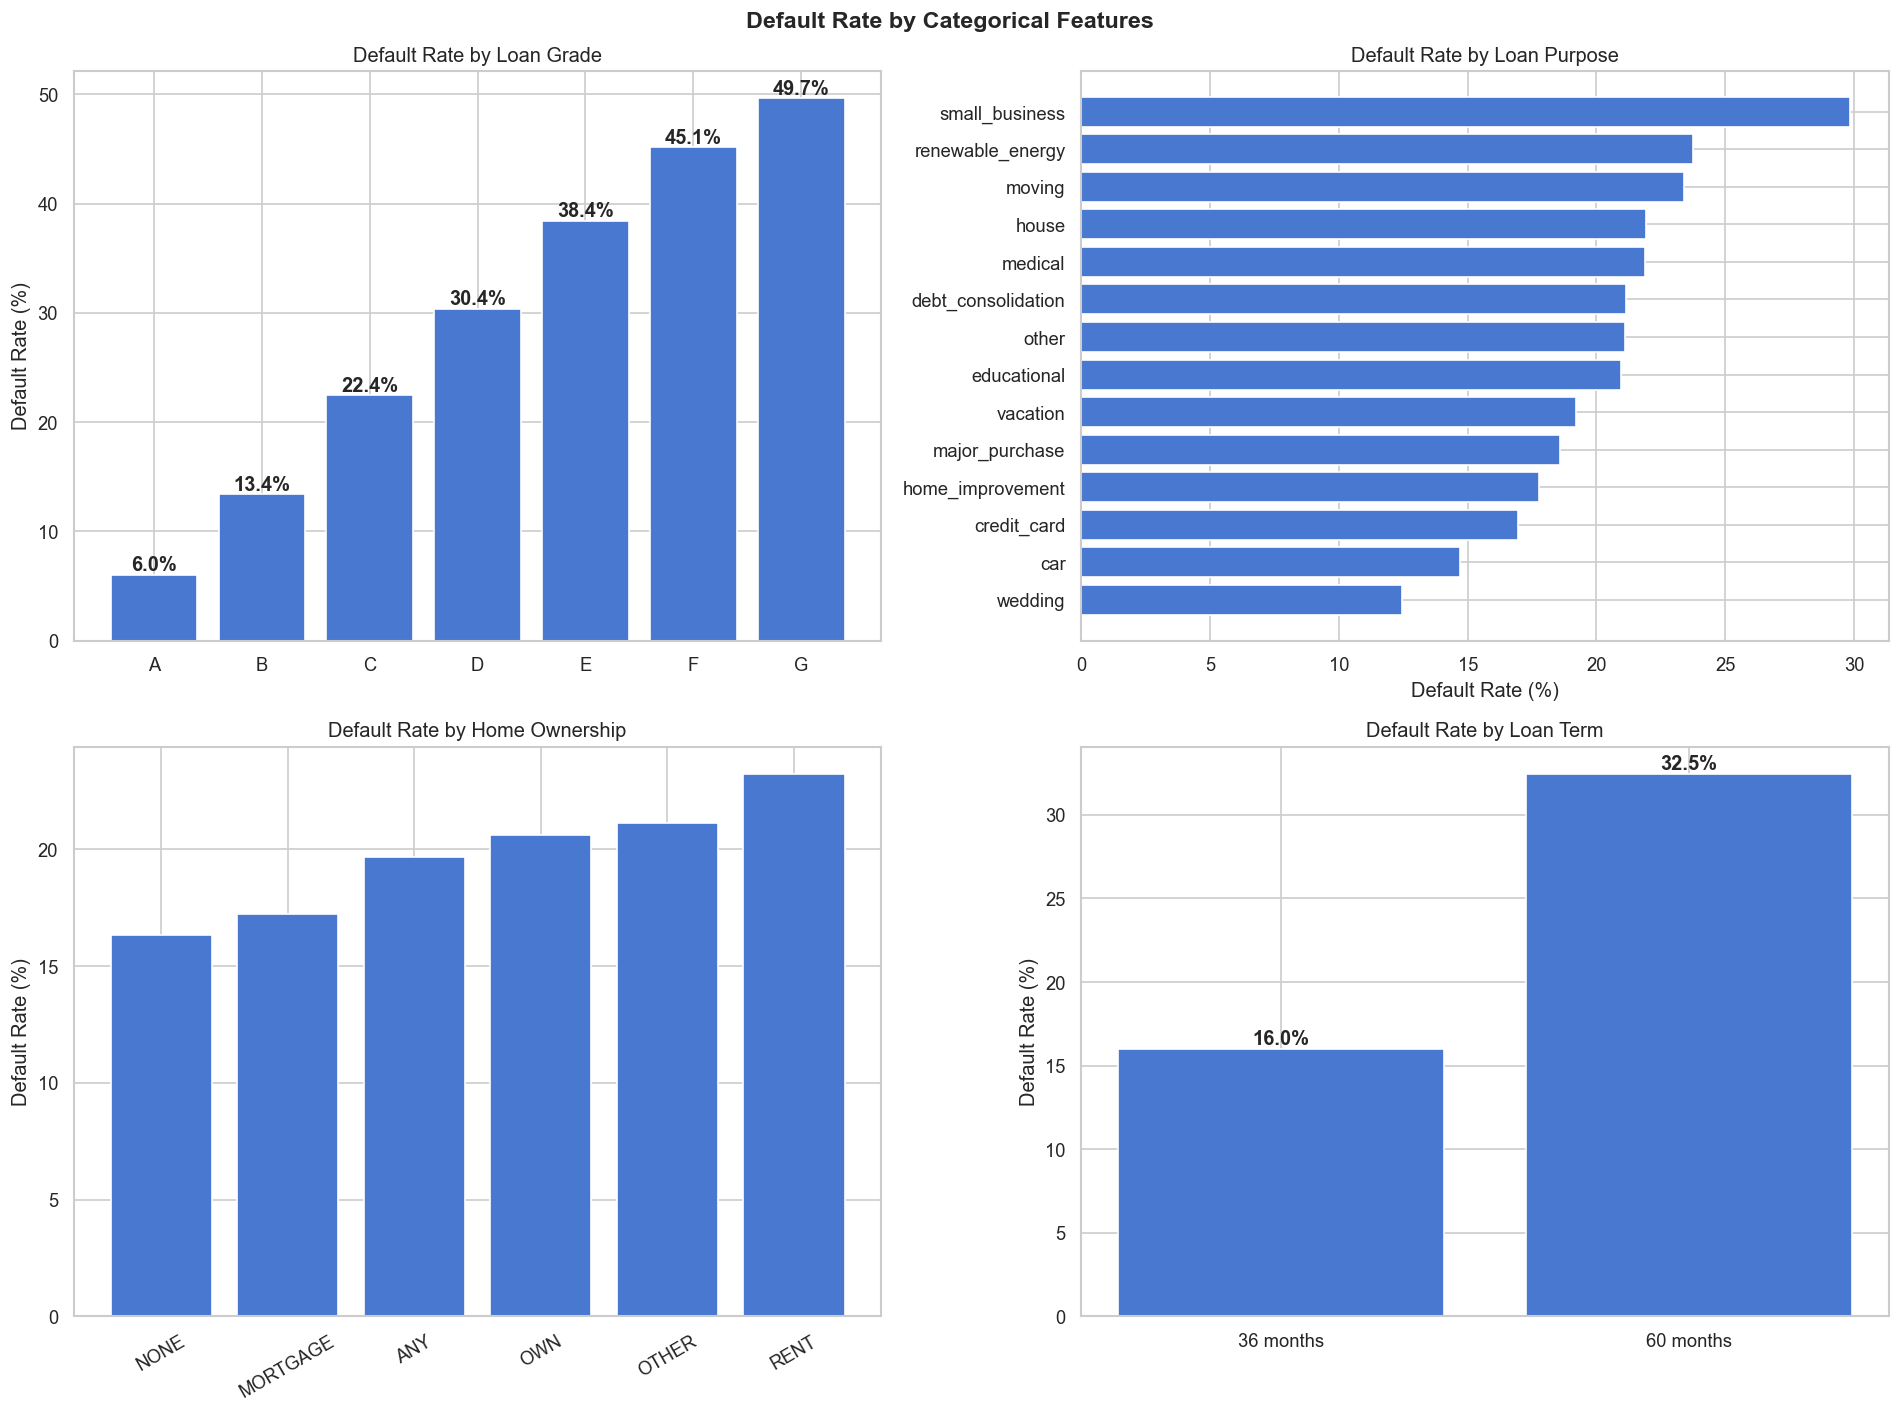

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Default rate by grade
grade_default = (
    df.groupby("grade")["target"]
    .mean()
    .reindex(["A", "B", "C", "D", "E", "F", "G"])
    * 100
)

axes[0, 0].bar(grade_default.index, grade_default.values)
axes[0, 0].set_title("Default Rate by Loan Grade")
axes[0, 0].set_ylabel("Default Rate (%)")

for i, value in enumerate(grade_default.values):
    axes[0, 0].text(i, value, f"{value:.1f}%", ha="center", va="bottom", fontweight="bold")

# 2. Default rate by purpose
purpose_default = (
    df.groupby("purpose")["target"]
    .mean()
    .sort_values(ascending=True)
    * 100
)

axes[0, 1].barh(purpose_default.index, purpose_default.values)
axes[0, 1].set_title("Default Rate by Loan Purpose")
axes[0, 1].set_xlabel("Default Rate (%)")

# 3. Default rate by home ownership
home_default = (
    df.groupby("home_ownership")["target"]
    .mean()
    .sort_values(ascending=True)
    * 100
)

axes[1, 0].bar(home_default.index, home_default.values)
axes[1, 0].set_title("Default Rate by Home Ownership")
axes[1, 0].set_ylabel("Default Rate (%)")
axes[1, 0].tick_params(axis="x", rotation=30)

# 4. Default rate by term
term_default = (
    df.groupby("term_label")["target"]
    .mean()
    .reindex(["36 months", "60 months"])
    * 100
)

axes[1, 1].bar(term_default.index, term_default.values)
axes[1, 1].set_title("Default Rate by Loan Term")
axes[1, 1].set_ylabel("Default Rate (%)")

for i, value in enumerate(term_default.values):
    axes[1, 1].text(i, value, f"{value:.1f}%", ha="center", va="bottom", fontweight="bold")

plt.suptitle("Default Rate by Categorical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("../report/plots/04_default_by_categorical_features.png", bbox_inches="tight")
plt.show()

### Insight: Default Rate by Categorical Features

Default risk increases sharply as loan grade worsens. Grade A loans have a default rate of around 6.0%, while Grade G loans have a default rate close to 49.7%. This shows that loan grade is one of the strongest categorical indicators of credit risk.

Loan term also has a strong relationship with default. 60-month loans have a default rate of around 32.5%, compared to only 16.0% for 36-month loans, indicating that longer-duration loans carry higher repayment risk.

By loan purpose, small business loans show the highest default rate at around 29.9%, while wedding and car loans show relatively lower default rates. For home ownership, renters show higher default risk than mortgage borrowers.

These findings suggest that loan grade, term, purpose, and home ownership are important risk indicators for credit risk modeling and business decision-making.

In [21]:
numeric_risk_cols = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_avg",
    "revol_util",
    "open_acc",
    "loan_to_income_ratio",
    "installment_to_income_ratio",
    "credit_history_years"
]

numeric_default_summary = df.groupby("target")[numeric_risk_cols].mean().T
numeric_default_summary.columns = ["Good_Loans_Mean", "Bad_Loans_Mean"]
numeric_default_summary["Difference"] = (
    numeric_default_summary["Bad_Loans_Mean"] - numeric_default_summary["Good_Loans_Mean"]
)

numeric_default_summary.round(2)

,Good_Loans_Mean,Bad_Loans_Mean,Difference
loan_amnt,14125.72,15548.93,1423.21
int_rate,12.62,15.71,3.08
annual_inc,75937.12,69300.99,-6636.13
dti,17.67,19.95,2.28
fico_avg,700.23,689.82,-10.41
revol_util,51.06,54.73,3.67
open_acc,11.48,11.85,0.37
loan_to_income_ratio,0.21,0.24,0.04
installment_to_income_ratio,0.08,0.09,0.01
credit_history_years,16.38,15.75,-0.63


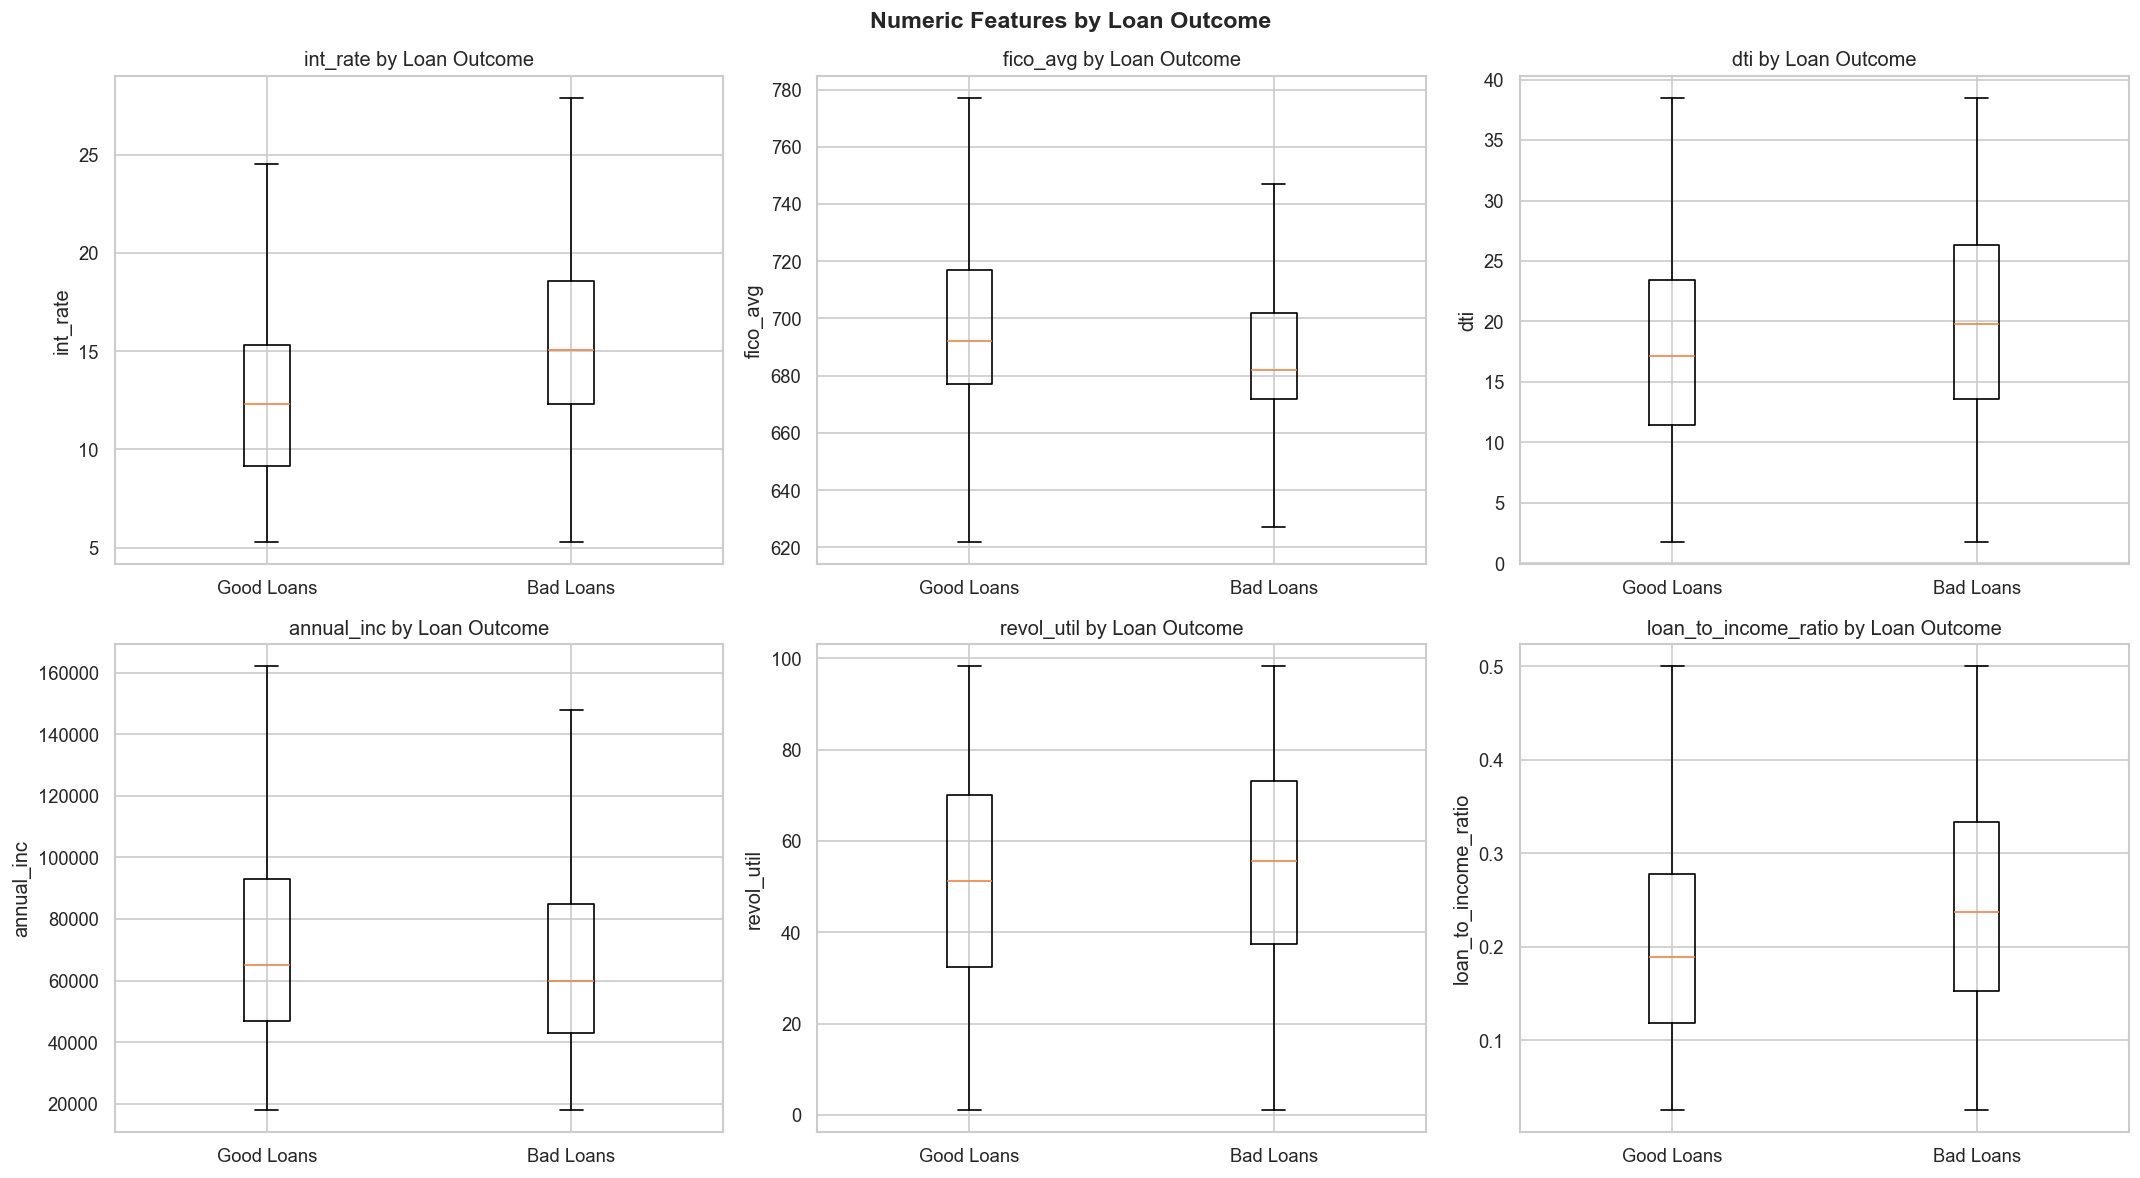

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

num_bivariate = [
    "int_rate",
    "fico_avg",
    "dti",
    "annual_inc",
    "revol_util",
    "loan_to_income_ratio"
]

for i, col in enumerate(num_bivariate):
    data_to_plot = [
        df[df["target"] == 0][col].dropna(),
        df[df["target"] == 1][col].dropna()
    ]

    axes[i].boxplot(
        data_to_plot,
        labels=["Good Loans", "Bad Loans"],
        showfliers=False
    )

    axes[i].set_title(f"{col} by Loan Outcome")
    axes[i].set_ylabel(col)

plt.suptitle("Numeric Features by Loan Outcome", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("../report/plots/05_numeric_features_by_default.png", bbox_inches="tight")
plt.show()

### Insight: Numeric Features by Loan Outcome

The numeric feature comparison shows clear differences between good and bad loans. Bad loans generally have higher interest rates, higher DTI, higher revolving utilization, and higher loan-to-income ratios. They also have lower average annual income and lower FICO scores compared to good loans.

This indicates that defaulted borrowers tend to have higher repayment burden and weaker credit profiles. These variables are likely to be important predictors in the machine learning phase.

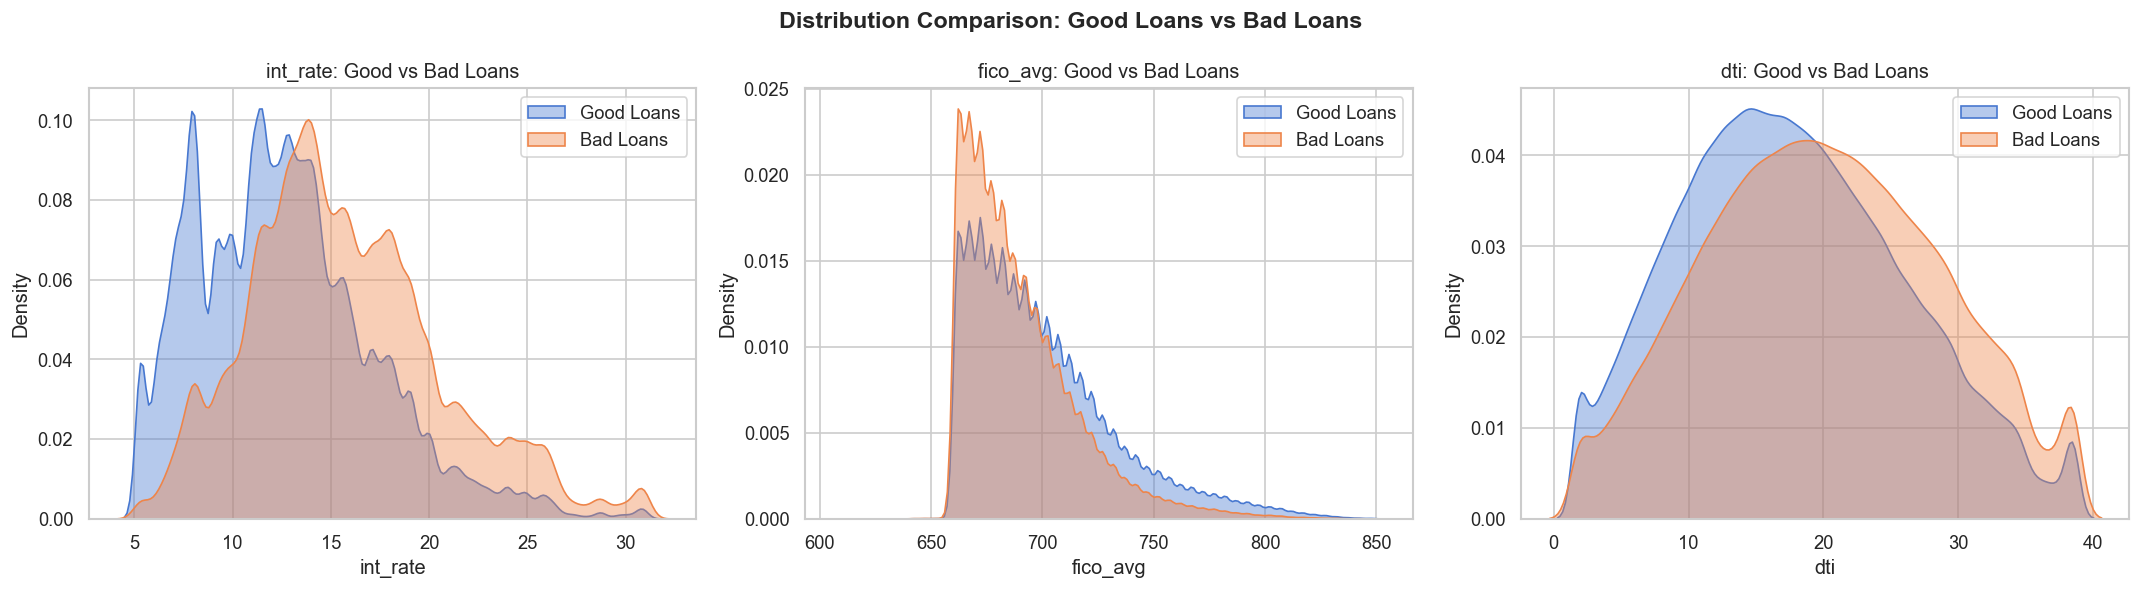

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

kde_cols = ["int_rate", "fico_avg", "dti"]

for i, col in enumerate(kde_cols):
    sns.kdeplot(
        data=df[df["target"] == 0],
        x=col,
        ax=axes[i],
        label="Good Loans",
        fill=True,
        alpha=0.4
    )
    sns.kdeplot(
        data=df[df["target"] == 1],
        x=col,
        ax=axes[i],
        label="Bad Loans",
        fill=True,
        alpha=0.4
    )

    axes[i].set_title(f"{col}: Good vs Bad Loans")
    axes[i].legend()

plt.suptitle("Distribution Comparison: Good Loans vs Bad Loans", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("../report/plots/06_kde_good_vs_bad_loans.png", bbox_inches="tight")
plt.show()

### Insight: Distribution Comparison of Good and Bad Loans

The KDE plots show that good and bad loans have overlapping distributions, meaning no single numeric feature can perfectly separate defaulters from non-defaulters.

However, bad loans are clearly shifted toward higher interest rates and higher DTI values, while good loans are shifted toward higher FICO scores. This confirms that default risk is influenced by multiple borrower and loan characteristics together.

Because the distributions overlap, a machine learning model using multiple features is more suitable than a simple rule-based cutoff.

In [24]:
vintage = df.groupby("issue_year").agg(
    total_loans=("target", "count"),
    bad_loans=("target", "sum"),
    default_rate=("target", "mean")
).reset_index()

vintage["default_rate_pct"] = (vintage["default_rate"] * 100).round(2)

print(vintage)

    issue_year  total_loans  bad_loans  default_rate  default_rate_pct
0         2007          571        153      0.267951             26.80
1         2008         2381        492      0.206636             20.66
2         2009         5265        720      0.136752             13.68
3         2010        12516       1751      0.139901             13.99
4         2011        21712       3293      0.151667             15.17
5         2012        53320       8633      0.161909             16.19
6         2013       134726      21013      0.155968             15.60
7         2014       222988      41139      0.184490             18.45
8         2015       375390      75768      0.201838             20.18
9         2016       292879      68207      0.232885             23.29
10        2017       168988      39095      0.231348             23.13
11        2018        56093       8839      0.157578             15.76


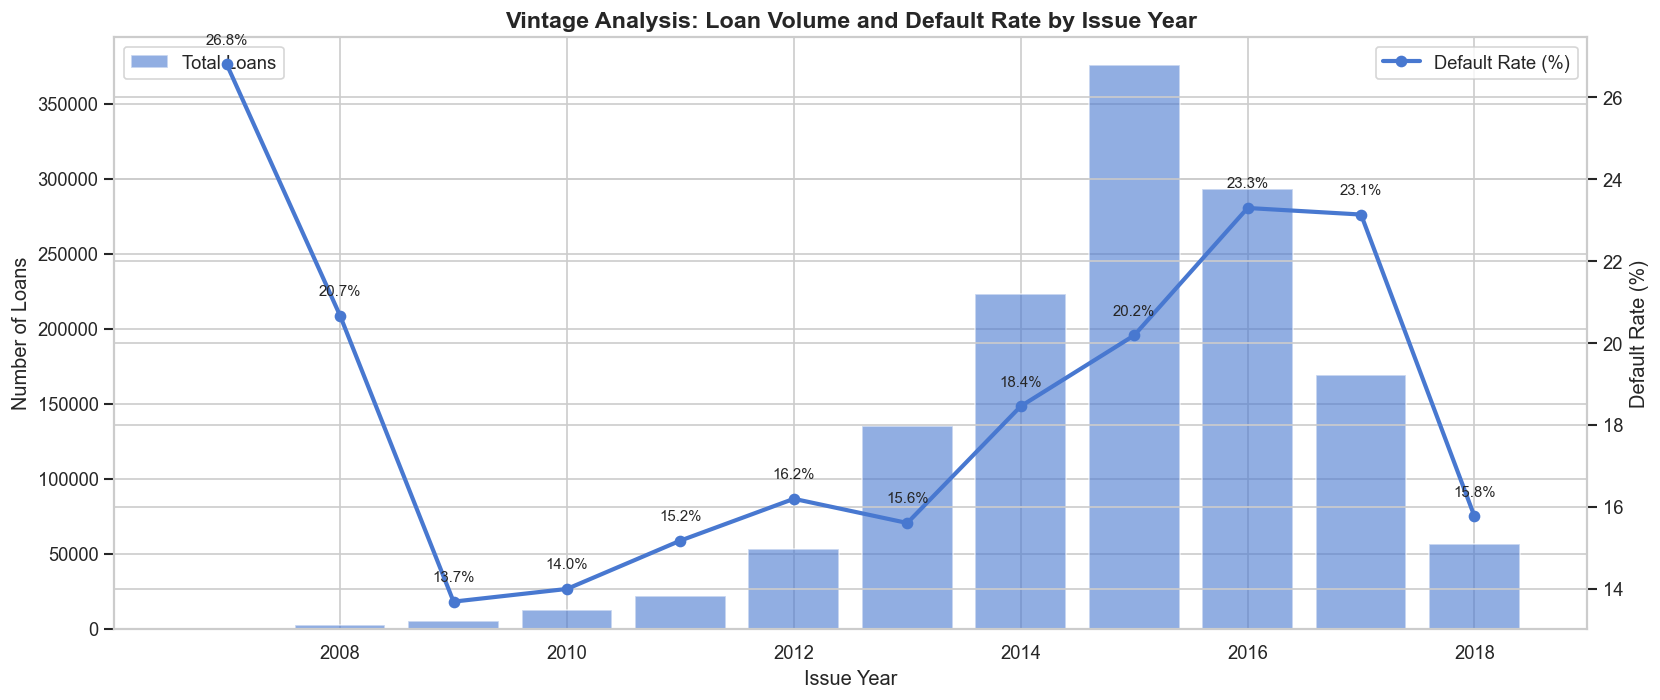

In [25]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax2 = ax1.twinx()

# Bar chart: total loans
ax1.bar(
    vintage["issue_year"],
    vintage["total_loans"],
    alpha=0.6,
    label="Total Loans"
)

ax1.set_xlabel("Issue Year")
ax1.set_ylabel("Number of Loans")

# Line chart: default rate
ax2.plot(
    vintage["issue_year"],
    vintage["default_rate_pct"],
    marker="o",
    linewidth=2.5,
    label="Default Rate (%)"
)

ax2.set_ylabel("Default Rate (%)")

plt.title("Vintage Analysis: Loan Volume and Default Rate by Issue Year", fontsize=14, fontweight="bold")

# Add default rate labels
for x, y in zip(vintage["issue_year"], vintage["default_rate_pct"]):
    ax2.text(x, y + 0.5, f"{y:.1f}%", ha="center", fontsize=9)

# Legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()

plt.savefig("../report/plots/07_vintage_analysis.png", bbox_inches="tight")
plt.show()

### Insight: Vintage Analysis

The vintage analysis shows that default rates vary significantly by loan issue year. Loans issued in 2007 show the highest default rate at around 26.8%, while 2009–2013 show comparatively lower default rates.

Default rates increased again during 2015–2017, reaching around 23% in 2016 and 2017. This shows that credit risk is influenced not only by borrower-level features but also by time-based portfolio and economic conditions.

Loan volume increased strongly after 2012 and peaked around 2015, indicating expansion in lending activity during that period.

In [26]:
state_stats = df.groupby("addr_state").agg(
    total_loans=("target", "count"),
    bad_loans=("target", "sum"),
    default_rate=("target", "mean")
).reset_index()

state_stats["default_rate_pct"] = (state_stats["default_rate"] * 100).round(2)

# Keep states with enough loan volume
state_stats_filtered = state_stats[state_stats["total_loans"] > 100].copy()

print("Top 10 highest default rate states:")
print(state_stats_filtered.sort_values("default_rate_pct", ascending=False).head(10))

print("\nTop 10 lowest default rate states:")
print(state_stats_filtered.sort_values("default_rate_pct", ascending=True).head(10))

Top 10 highest default rate states:
   addr_state  total_loans  bad_loans  default_rate  default_rate_pct
25         MS         6588       1722      0.261384             26.14
29         NE         3588        904      0.251951             25.20
2          AR        10048       2424      0.241242             24.12
1          AL        16622       3925      0.236133             23.61
36         OK        12280       2881      0.234609             23.46
18         LA        15496       3590      0.231673             23.17
34         NY       109997      24262      0.220570             22.06
33         NV        20266       4455      0.219826             21.98
9          FL        95763      20591      0.215020             21.50
15         IN        21714       4655      0.214378             21.44

Top 10 lowest default rate states:
   addr_state  total_loans  bad_loans  default_rate  default_rate_pct
7          DC         3477        461      0.132586             13.26
21         ME     

In [27]:
state_stats_filtered.to_csv("../data/exports/state_default_stats.csv", index=False)

print("State default stats saved successfully.")
print(state_stats_filtered.shape)

State default stats saved successfully.
(50, 5)


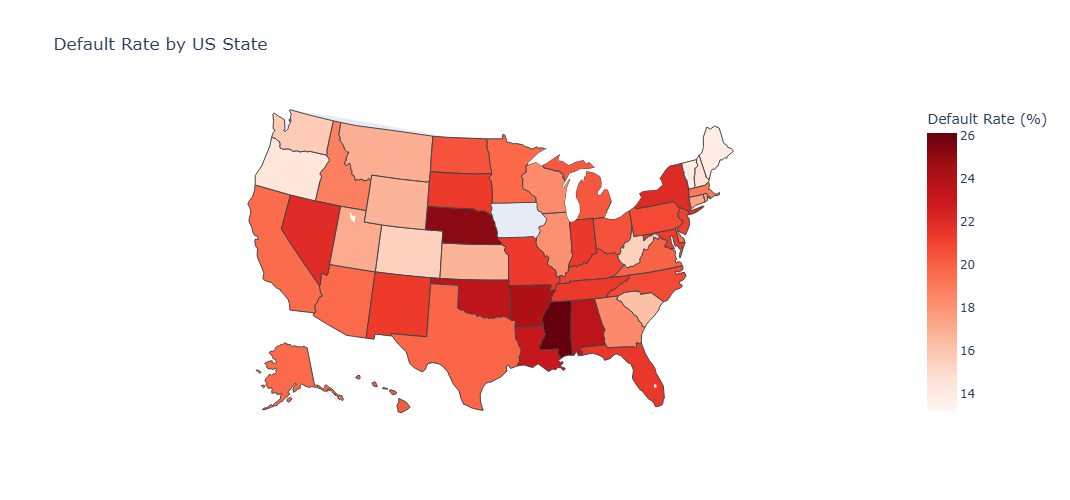

In [28]:
fig = px.choropleth(
    state_stats_filtered,
    locations="addr_state",
    locationmode="USA-states",
    color="default_rate_pct",
    scope="usa",
    color_continuous_scale="Reds",
    hover_name="addr_state",
    hover_data={
        "total_loans": True,
        "bad_loans": True,
        "default_rate_pct": True
    },
    labels={"default_rate_pct": "Default Rate (%)"},
    title="Default Rate by US State"
)

fig.update_layout(height=500)

fig.write_html("../report/plots/08_state_choropleth.html")
fig.show()

### Insight: Geographic Default Risk

The geographic analysis shows that default risk varies across US states. Mississippi, Nebraska, Arkansas, Alabama, and Oklahoma show some of the highest default rates, while DC, Maine, Vermont, Oregon, and New Hampshire show some of the lowest default rates.

This suggests that borrower geography may reflect regional economic differences, employment patterns, income levels, and credit behavior. The exported state-level default statistics can be reused later for SQL analysis and dashboard development.

In [29]:
corr_cols = [
    "loan_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "fico_avg",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "loan_to_income_ratio",
    "installment_to_income_ratio",
    "credit_history_years",
    "target"
]

corr_matrix = df[corr_cols].corr()

target_corr = corr_matrix["target"].drop("target").sort_values(key=abs, ascending=False)

print("Top correlations with target:")
print(target_corr)

Top correlations with target:
int_rate                       0.258618
loan_to_income_ratio           0.138670
fico_avg                      -0.130741
installment_to_income_ratio    0.121445
dti                            0.108163
mort_acc                      -0.075270
loan_amnt                      0.065304
annual_inc                    -0.063019
revol_util                     0.059991
installment                    0.051423
credit_history_years          -0.033530
open_acc                       0.027992
pub_rec                        0.026157
revol_bal                     -0.019634
delinq_2yrs                    0.019249
total_acc                     -0.011350
Name: target, dtype: float64


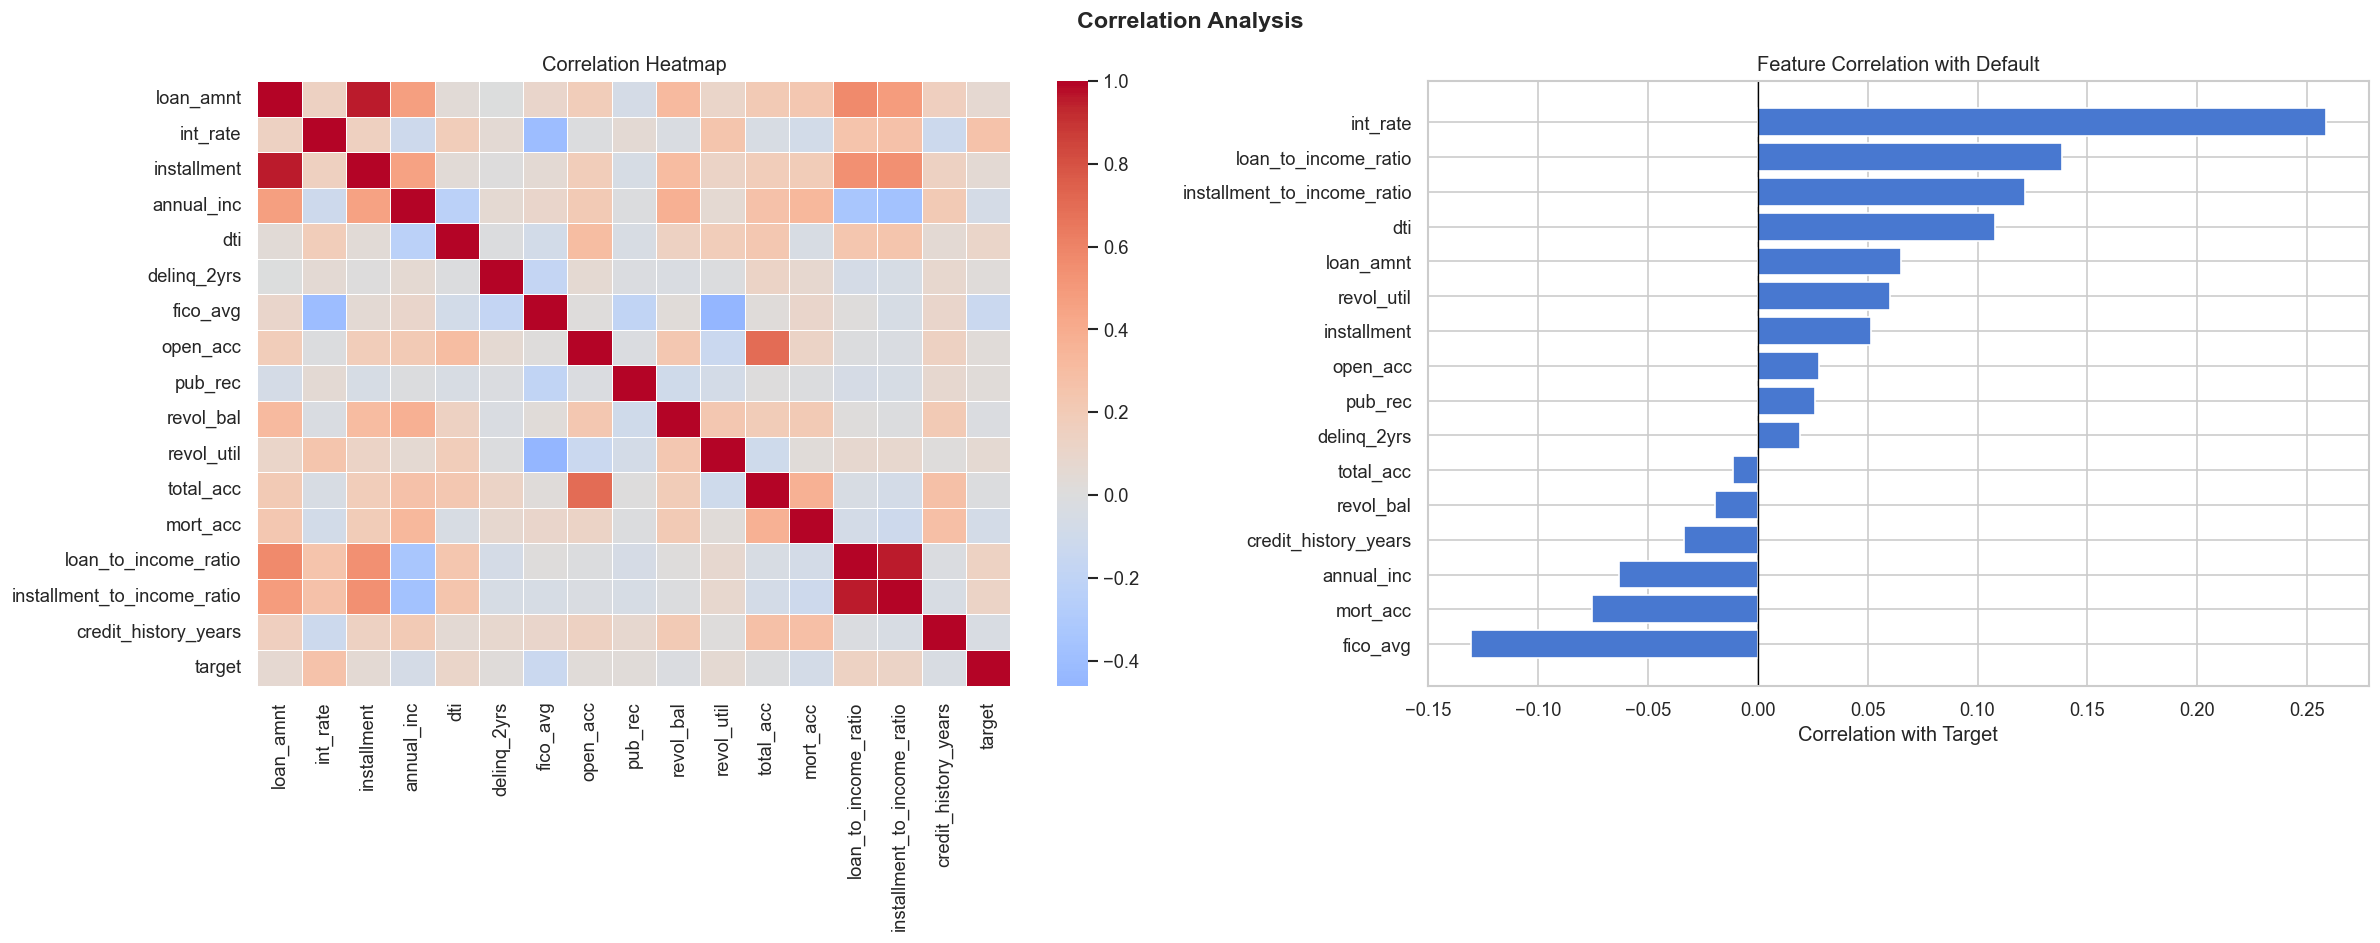

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.3,
    ax=axes[0]
)

axes[0].set_title("Correlation Heatmap")

# Target correlation bar chart
target_corr_sorted = target_corr.sort_values()

axes[1].barh(target_corr_sorted.index, target_corr_sorted.values)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Feature Correlation with Default")
axes[1].set_xlabel("Correlation with Target")

plt.suptitle("Correlation Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("../report/plots/09_correlation_analysis.png", bbox_inches="tight")
plt.show()

### Insight: Correlation Analysis

The correlation analysis shows that `int_rate` has the strongest positive correlation with default, indicating that higher interest rates are associated with higher default risk. Other repayment burden variables such as `loan_to_income_ratio`, `installment_to_income_ratio`, and `dti` also show positive relationships with default.

`fico_avg` has the strongest negative correlation with default, meaning borrowers with higher FICO scores are less likely to default. Annual income and credit history years also show negative relationships with default, suggesting that stronger financial and credit profiles reduce risk.

Although these correlations are not extremely high individually, they show meaningful directional patterns. This supports the need for a machine learning model that combines multiple borrower, loan, and credit features to predict default risk.

## Phase 3 EDA Findings Summary

1. The dataset has a moderate class imbalance, with approximately 80.02% good loans and 19.98% bad loans.

2. Loan grade is one of the strongest categorical risk indicators. Default rate increases from around 6.0% for Grade A loans to around 49.7% for Grade G loans.

3. Loan term has a strong relationship with default. 60-month loans have a default rate of around 32.5%, almost double the 16.0% default rate of 36-month loans.

4. Small business loans show the highest default rate by purpose at around 29.9%, while car and wedding loans show comparatively lower default rates.

5. Renters show higher default risk than mortgage borrowers, suggesting that home ownership status may capture borrower stability.

6. Bad loans generally have higher interest rates, higher DTI, higher revolving utilization, and higher loan-to-income ratios compared to good loans.

7. Bad loans also have lower average annual income, lower FICO scores, and slightly shorter credit history compared to good loans.

8. KDE plots show that good and bad loans have overlapping distributions, meaning no single variable can perfectly separate defaulters from non-defaulters.

9. Vintage analysis shows that default rates vary by issue year, with 2007 and 2015–2017 showing higher default rates.

10. Geographic analysis shows state-level variation in default risk. Mississippi, Nebraska, Arkansas, Alabama, and Oklahoma show some of the highest default rates.

11. Correlation analysis shows that `int_rate`, `loan_to_income_ratio`, `installment_to_income_ratio`, and `dti` are positively associated with default, while `fico_avg`, `annual_inc`, and `credit_history_years` are negatively associated with default.

Overall, EDA confirms that default risk is influenced by a combination of borrower credit quality, repayment burden, loan characteristics, time-based trends, and geographic factors.